# Simulating random point patterns with `pointpats.random`

This notebook illustrates how to use the `pointpats.random` module to simulate
random point patterns inside a study region (the *hull*).

We will look at several families of random patterns:

1. **Homogeneous Poisson** (`random.poisson`)
2. **Normal cluster** (`random.normal`)
3. **Poisson cluster (Neyman–Scott)** (`random.cluster_poisson`)
4. **Normal cluster with random seeds** (`random.cluster_normal`)

All examples use a simple square window as the hull:

$$[0, 1] \times [0, 1].$$


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import shapely
from shapely.geometry import Polygon, Point

from pointpats import random as ppr  # pointpats.random

# Make results reproducible
rng = np.random.default_rng(12345)

# Define a simple square hull as a bounding box:
# [xmin, ymin, xmax, ymax]
hull = np.array([0.0, 0.0, 1.0, 1.0])

hull

array([0., 0., 1., 1.])

## Helper function for plotting point patterns

We'll use a small helper to visualize realizations of the random point processes.

In [17]:
def plot_pattern(points, hull, ax=None, title=None):
    """Plot a 2D point pattern inside a rectangular hull.

    Parameters
    ----------
    points : array-like, shape (n_points, 2)
        Coordinates of the points.
    hull : array-like, shape (4,)
        Bounding box [xmin, ymin, xmax, ymax].
    ax : matplotlib.axes.Axes, optional
        Axis to plot on.
    title : str, optional
        Title for the plot.
    """
    points = np.asarray(points)

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))

    xmin, ymin, xmax, ymax = hull
    ax.scatter(points[:, 0], points[:, 1], s=10, alpha=0.7)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    if title:
        ax.set_title(title)

    return ax

## 1. Homogeneous Poisson process (`random.poisson`)

The **homogeneous Poisson point process** is the canonical model of
*complete spatial randomness* (CSR):

- Each point is independently and uniformly distributed in the hull.
- The expected number of points is controlled by the **intensity**
  (points per unit area).

A typical interface (check the installed `pointpats` version for details) allows usage patterns like:

- `poisson(hull, size=n)` — simulate `n` points once.
- `poisson(hull, intensity=lambda_, size=r)` — draw `r` *replications* from a Poisson
  process with intensity `lambda_` points per unit area.


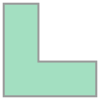

In [18]:
window =  [(1, 1), (1, 9), (4, 9), (4, 4), (9, 4), (9, 1)]
window = Polygon(window)
window

In [19]:
points = ppr.poisson(window, size=100, rng=rng)
shapely_points = shapely.points(points[:, 0], points[:, 1])
min_distances_fast = shapely.distance(shapely_points, window.boundary)

In [20]:
W = gpd.GeoDataFrame(geometry=[window])

In [21]:
pnt_df = gpd.GeoDataFrame(geometry=shapely_points,
                         data=min_distances_fast,
                         columns=['d2w'])

<Axes: >

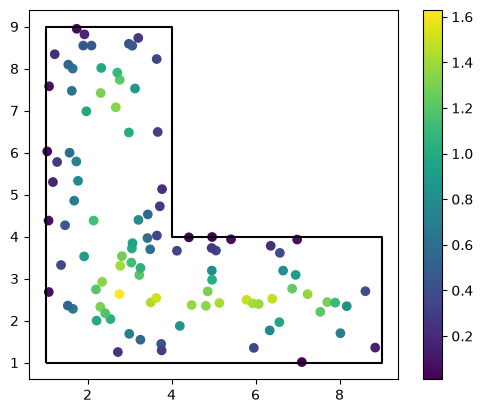

In [22]:
base = W.boundary.plot(color='k')
pnt_df.plot(column='d2w', legend=True, ax=base)

## Determine maximum radius for k functions

In [23]:
from pointpats.geometry import max_radius

In [24]:
max_radius(W)

np.float64(4.0)

In [25]:
max_radius(W, points, method='distance_pct')

2.0504424990928616

In [26]:
max_radius(W, points, method='distance_pct', pct=.5)

3.573200566076835

In [27]:
max_r, core_polygon = max_radius(W, points, method='erosion_threshold')
max_r

0.7333180123594873

In [28]:
core_polygon.area

0    17.800926
dtype: float64

In [29]:
W.area

0    39.0
dtype: float64

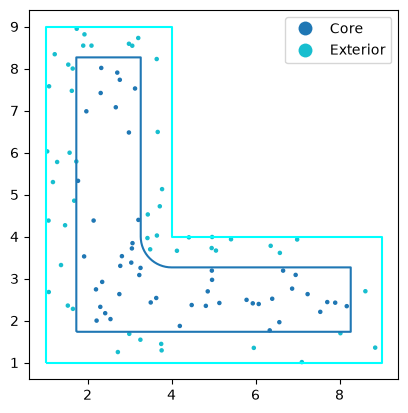

In [30]:
base = W.boundary.plot(edgecolor='cyan')
core_polygon.boundary.plot(ax=base)
core = np.array([core_polygon.contains(Point(pnt)) for pnt in points]).squeeze()
pnt_df['core'] = np.where(core, "Core", "Exterior")
pnt_df.plot(column='core', legend=True, categorical=True,ax=base,
           markersize=5);

## local k

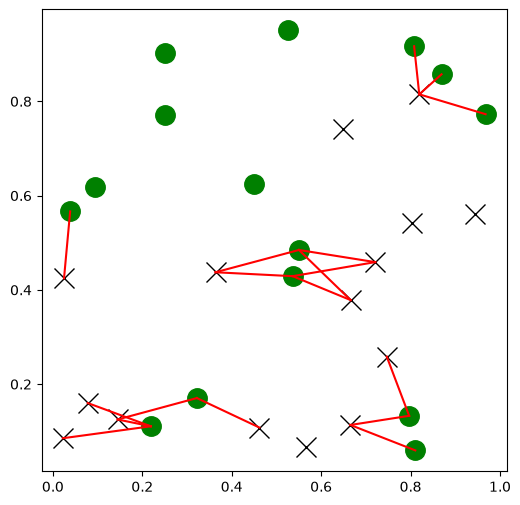

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import KDTree
rng = np.random.default_rng()
points1 = rng.random((15, 2))
points2 = rng.random((15, 2))
plt.figure(figsize=(6, 6))
plt.plot(points1[:, 0], points1[:, 1], "xk", markersize=14)
plt.plot(points2[:, 0], points2[:, 1], "og", markersize=14)
kd_tree1 = KDTree(points1)
kd_tree2 = KDTree(points2)
indexes = kd_tree1.query_ball_tree(kd_tree2, r=0.2)
for i in range(len(indexes)):
    for j in indexes[i]:
        plt.plot([points1[i, 0], points2[j, 0]],
            [points1[i, 1], points2[j, 1]], "-r")
plt.show()

In [42]:
tree = KDTree(points_poisson_fixed)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [43]:
indexes = tree.query_ball_tree(tree, r=0.1)

In [45]:
type(indexes)

list

In [48]:
kirs = counts = np.array([len(neighbors) - 1 for neighbors in indexes])

In [49]:
kirs

array([7, 6, 3, 3, 1, 3, 3, 0, 2, 2, 4, 3, 1, 4, 2, 3, 1, 4, 0, 5, 1, 3,
       7, 8, 2, 2, 5, 5, 5, 3, 6, 6, 4, 6, 3, 4, 3, 3, 4, 0, 4, 1, 3, 1,
       1, 2, 4, 4, 3, 3, 5, 3, 3, 6, 6, 4, 3, 2, 1, 3, 6, 2, 2, 2, 3, 5,
       3, 2, 4, 0, 2, 2, 2, 0, 0, 3, 3, 6, 5, 3, 1, 2, 6, 3, 4, 1, 4, 2,
       3, 3, 6, 2, 7, 1, 8, 3, 3, 5, 2, 0])

In [62]:
kirs = np.array([
    [len(neighbors) - 1 for neighbors in tree.query_ball_tree(tree, r)]
    for r in rs
]).T

In [63]:
kirs.shape

(100, 6)

In [65]:
kirs[:,0]

array([3, 1, 0, 2, 1, 2, 1, 0, 1, 1, 0, 1, 0, 2, 0, 1, 0, 2, 0, 1, 0, 0,
       3, 3, 0, 1, 2, 1, 1, 2, 4, 2, 3, 2, 1, 2, 1, 0, 1, 0, 2, 0, 1, 0,
       0, 0, 2, 0, 2, 0, 1, 1, 0, 1, 2, 0, 2, 0, 0, 1, 1, 0, 0, 0, 2, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 2, 0, 2, 2, 0, 0, 2, 0, 1, 1, 1, 0,
       1, 0, 2, 0, 1, 1, 2, 1, 1, 2, 0, 0])

In [66]:
kirs[0]

array([ 3,  8, 18, 28, 43, 47])

In [67]:
kirs[:,-1]

array([47, 31, 54, 44, 23, 17, 30, 24, 43, 33, 28, 50, 25, 35, 36, 28, 22,
       19, 25, 52, 42, 20, 49, 48, 24, 35, 40, 53, 39, 48, 48, 47, 50, 51,
       26, 24, 37, 28, 36, 44, 39, 40, 17, 46, 47, 27, 19, 54, 17, 33, 41,
       28, 49, 53, 48, 38, 19, 15, 25, 19, 53, 48, 31, 16, 49, 20, 37, 48,
       33, 20, 31, 28, 36, 19, 15, 23, 50, 49, 37, 17, 21, 31, 50, 21, 22,
       22, 37, 41, 16, 32, 35, 19, 52, 21, 53, 29, 22, 49, 45, 41])

In [68]:
def k0(n, r, lam):
    return n * np.pi * r * r

In [69]:
k0(100, .05, 100)

0.7853981633974484

In [71]:
def pk0(ki, k0):
    return np.exp(-k0) * (k0)**(ki) / (np.prod(np.arange(1, ki + 1)))

In [72]:
pk0(3, 0.785)

np.float64(0.036773634189631935)

In [73]:
import numpy as np
from scipy.stats import poisson

# Define parameters
lam = 3.5  # Mean rate (lambda)
k = 5      # Calculate P(X > 5)

# Calculate the survival probability
sf_value = poisson.sf(k, mu=lam)

print(f"P(X > {k}) = {sf_value:.6f}")
# Output: P(X > 5) = 0.142386

P(X > 5) = 0.142386


In [74]:
import numpy as np
from scipy.stats import poisson

# Define your average event rate (lambda / mu)
lam = 15.0

# Calculate the lower and upper quantiles
q_lower = poisson.ppf(0.025, mu=lam)
q_upper = poisson.ppf(0.975, mu=lam)

print(f"For Lambda = {lam}:")
print(f"0.025 Quantile (Lower): {q_lower}")
print(f"0.975 Quantile (Upper): {q_upper}")

For Lambda = 15.0:
0.025 Quantile (Lower): 8.0
0.975 Quantile (Upper): 23.0


In [79]:
lam = 100
lower_env = np.array([poisson.ppf(0.025, lam*np.pi * r**2) for r in rs])
upper_env = np.array([poisson.ppf(0.975, lam*np.pi * r**2) for r in rs])



In [80]:
lower_env, upper_env

(array([ 0.,  1.,  5., 13., 23., 37.]), array([ 3.,  9., 18., 31., 46., 65.]))

In [81]:
kirs[:,-1]

array([47, 31, 54, 44, 23, 17, 30, 24, 43, 33, 28, 50, 25, 35, 36, 28, 22,
       19, 25, 52, 42, 20, 49, 48, 24, 35, 40, 53, 39, 48, 48, 47, 50, 51,
       26, 24, 37, 28, 36, 44, 39, 40, 17, 46, 47, 27, 19, 54, 17, 33, 41,
       28, 49, 53, 48, 38, 19, 15, 25, 19, 53, 48, 31, 16, 49, 20, 37, 48,
       33, 20, 31, 28, 36, 19, 15, 23, 50, 49, 37, 17, 21, 31, 50, 21, 22,
       22, 37, 41, 16, 32, 35, 19, 52, 21, 53, 29, 22, 49, 45, 41])

In [90]:
def local_envelope(n, A, radii, p=0.05):
    lam = n / A
    p2 = p / 2
    lower_e = np.array([poisson.ppf(p2, lam * np.pi * r**2) for r in radii])
    upper_e = np.array([poisson.ppf(1-p2, lam * np.pi * r**2) for r in radii])
    return np.column_stack([radii, lower_e, upper_e])

In [91]:
local_envelope(100, 1, rs)

array([[5.0e-02, 0.0e+00, 3.0e+00],
       [1.2e-01, 1.0e+00, 9.0e+00],
       [1.9e-01, 5.0e+00, 1.8e+01],
       [2.6e-01, 1.3e+01, 3.1e+01],
       [3.3e-01, 2.3e+01, 4.6e+01],
       [4.0e-01, 3.7e+01, 6.5e+01]])

Total dataset shape: (1100, 2)
Sweeping across radii: [0.1  0.28 0.46 0.64 0.82 1.  ]
Parameter sweep matrix shape (Points x Radii): (1100, 6)
Target Radius: 0.46
Theoretical Expected Neighbors (Lambda): 7.3124
95% Confidence Bounds under CSR: [3, 13]
Identified 110 point locations acting as density anomalies.


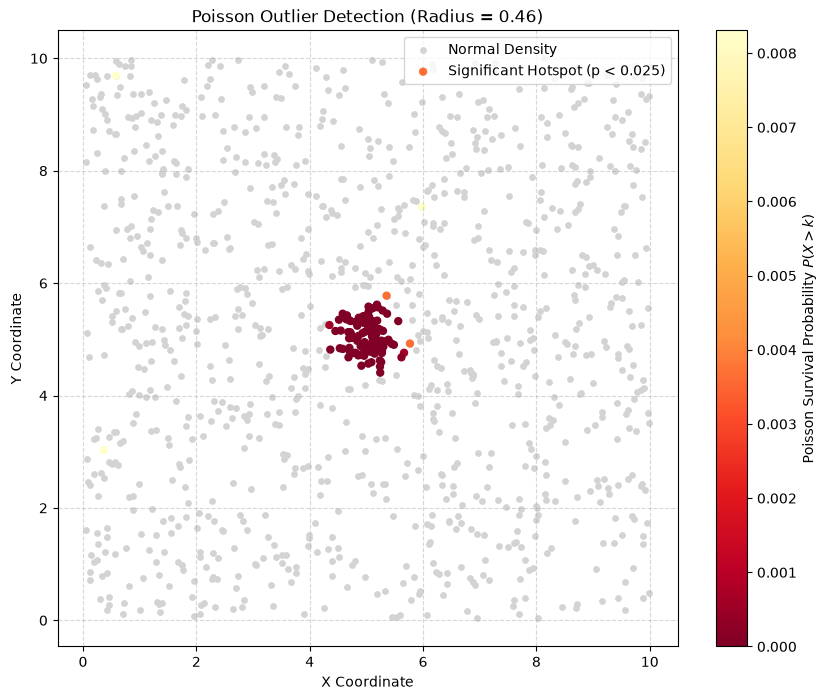

In [96]:
# %% [markdown]
# # Spatial Density Parameter Sweeps & Poisson Outlier Detection
# This notebook demonstrates how to efficiently perform a multi-radius neighbor 
# search using a spatial tree, extract neighbor counts, and evaluate those counts 
# against theoretical Poisson distribution boundaries and survival functions.

# %%
import numpy as np
import scipy.spatial as spatial
from scipy.stats import poisson
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# %% [markdown]
# ## 1. Generate Synthetic Spatial Point Pattern
# We create a baseline of 1,000 points uniformly distributed across a 
# 2D coordinate space, then inject a dense spatial cluster to test our detector.

# %%
n_points = 1000
# Base uniform distribution
coords = np.random.uniform(0, 10, size=(n_points, 2))

# Inject a dense localized cluster (simulate an outbreak or hotspot)
cluster_center = np.array([5.0, 5.0])
cluster_points = np.random.normal(loc=cluster_center, scale=0.3, size=(100, 2))
coords = np.vstack((coords, cluster_points))

print(f"Total dataset shape: {coords.shape}")

# %% [markdown]
# ## 2. Build Spatial Index Tree & Execute Parameter Sweep
# We instantiate a `KDTree` and perform an efficient search across a range 
# of search radii ($rs$). We pass the entire coordinates matrix into the tree
# while iterating across scalar radius inputs to ensure clean internal C-broadcasting.

# %%
# Build the spatial index
tree = spatial.KDTree(coords)

# Define our range of evaluation radii (rs)
rs = np.linspace(0.1, 1.0, 6)
print(f"Sweeping across radii: {rs}")

# Query the tree using vectorized radius sweeps to construct the counts matrix
# Shape results in (Points x Radii)
kirs_matrix = np.array([
    [len(neighbors) - 1 for neighbors in tree.query_ball_point(coords, r)] 
    for r in rs
]).T

print(f"Parameter sweep matrix shape (Points x Radii): {kirs_matrix.shape}")

# %% [markdown]
# ## 3. Evaluate Statistical Anomalies using the Poisson Distribution
# Assuming spatial randomness matches a homogeneous Poisson process, the expected 
# number of neighbors scales with the area of the search circle. We calculate the 
# global intensity ($\lambda$), find critical envelopes, and compute survival probabilities.

# %%
# Total study area bounding box dimensions
area = 10.0 * 10.0
num_total_points = tree.n
global_density = num_total_points / area

# Pick a target radius index to analyze (e.g., r = 0.46)
target_radius_idx = 2
r_target = rs[target_radius_idx]

# Expected neighborhood count (lambda) under Complete Spatial Randomness (CSR)
expected_lambda = global_density * (np.pi * (r_target ** 2))
observed_counts = kirs_matrix[:, target_radius_idx]

# Calculate theoretical Poisson 95% confidence intervals
lower_bound = poisson.ppf(0.025, mu=expected_lambda)
upper_bound = poisson.ppf(0.975, mu=expected_lambda)

# Compute survival probabilities P(X > k) for all observed locations
survival_probs = poisson.sf(observed_counts, mu=expected_lambda)

print(f"Target Radius: {r_target:.2f}")
print(f"Theoretical Expected Neighbors (Lambda): {expected_lambda:.4f}")
print(f"95% Confidence Bounds under CSR: [{int(lower_bound)}, {int(upper_bound)}]")

# Identify extreme spatial outliers (hotspots)
significant_hotspots = np.where(observed_counts > upper_bound)[0]
print(f"Identified {len(significant_hotspots)} point locations acting as density anomalies.")

# %% [markdown]
# ## 4. Visualize the Spatial Anomalies
# Let's map our point patterns and color-code them based on their calculated 
# Poisson survival probabilities.

# %%
plt.figure(figsize=(10, 8))
# Plot non-significant points in grey
plt.scatter(coords[:, 0], coords[:, 1], c='lightgrey', s=15, label='Normal Density')

# Highlight points exceeding the 0.975 quantile envelope
plt.scatter(coords[significant_hotspots, 0], coords[significant_hotspots, 1], 
            c=survival_probs[significant_hotspots], cmap='YlOrRd_r', s=25, 
            label='Significant Hotspot (p < 0.025)')

plt.colorbar(label='Poisson Survival Probability $P(X > k)$')
plt.title(f'Poisson Outlier Detection (Radius = {r_target:.2f})')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Edge correction

Generated 919 points strictly inside the complex boundary.
Core Points (Safe Centers): 374
Border Points (Neighbors Only): 545
Successfully calculated edge-corrected neighbor counts for all 374 core locations.


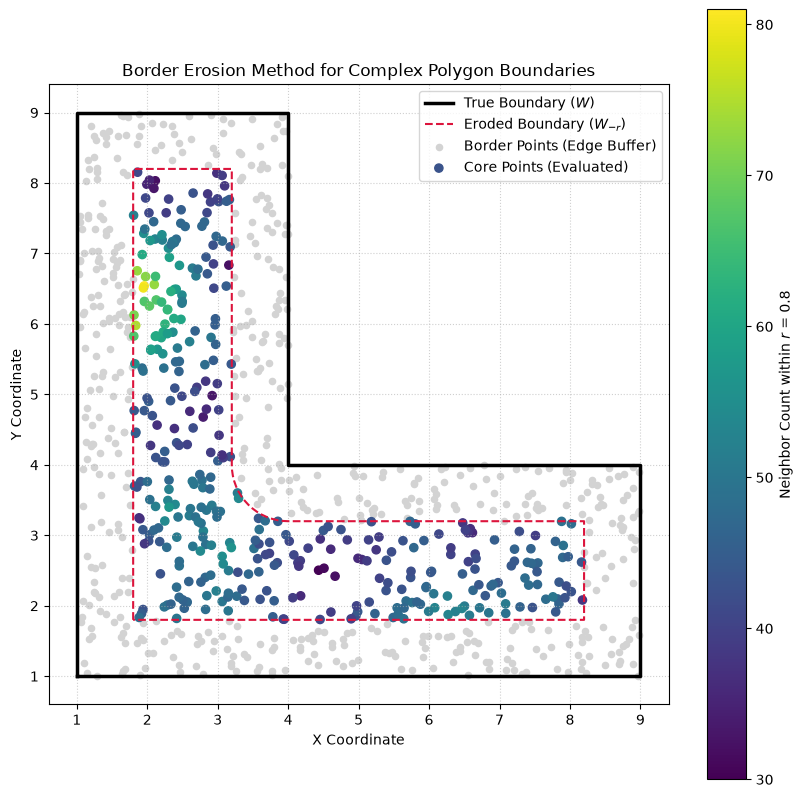

In [97]:
# %% [markdown]
# # Handling Complex Boundary Limitations via Border Erosion (Buffer Zones)
# This notebook demonstrates how to handle edge effects in complex, non-convex
# study boundaries using the Border Erosion method. Points near the boundary
# are restricted from acting as cluster origins, protecting the search radius from spilling out.

# %%
import numpy as np
import scipy.spatial as spatial
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point

# Set random seed for reproducibility
np.random.seed(42)

# %% [markdown]
# ## 1. Define a Complex, Non-Convex Study Boundary
# Instead of a simple square, we construct an irregular, L-shaped/crescent 
# polygon to simulate a complex real-world boundary (like a watershed or city limit).

# %%
# Define vertices for an irregular L-shaped study window
boundary_vertices = [(1, 1), (1, 9), (4, 9), (4, 4), (9, 4), (9, 1)]
study_area = Polygon(boundary_vertices)

# Generate uniform candidate points within a bounding box and filter them by the polygon
n_candidates = 1500
bbox_x = np.random.uniform(1, 9, n_candidates)
bbox_y = np.random.uniform(1, 9, n_candidates)

points_inside = []
for x, y in zip(bbox_x, bbox_y):
    p = Point(x, y)
    if study_area.contains(p):
        points_inside.append([x, y])

coords = np.array(points_inside)
print(f"Generated {len(coords)} points strictly inside the complex boundary.")

# %% [markdown]
# ## 2. Implement Border Erosion (Interior Buffering)
# We choose a target evaluation radius $r$. Any point closer than $r$ to the 
# boundary is classified as a "border point" (used only as a neighbor). Points further
# than $r$ are "core points" (safe to use as search centers).

# %%
# Define our evaluation search radius
r_search = 0.8

# Erode the study area boundary inward by the search radius
eroded_area = study_area.buffer(-r_search)

# Classify points based on whether they fall inside the eroded core
core_indices = []
border_indices = []

for idx, (x, y) in enumerate(coords):
    p = Point(x, y)
    if eroded_area.contains(p):
        core_indices.append(idx)
    else:
        border_indices.append(idx)

core_coords = coords[core_indices]
border_coords = coords[border_indices]

print(f"Core Points (Safe Centers): {len(core_coords)}")
print(f"Border Points (Neighbors Only): {len(border_coords)}")

# %% [markdown]
# ## 3. Execute Boundary-Safe Neighborhood Search
# We build a standard KDTree out of *all* points so no spatial neighbors are lost.
# However, we only query the tree using the coordinates of our *core points*.

# %%
# Build the tree using the entire point pool
tree = spatial.KDTree(coords)

# Query the tree using ONLY the core point coordinates
# This guarantees no search circle spills outside the true study boundary
neighbor_lists = tree.query_ball_point(core_coords, r_search)

# Calculate neighborhood counts (subtracting 1 to omit self-counts)
core_counts = np.array([len(neighbors) - 1 for neighbors in neighbor_lists])

print(f"Successfully calculated edge-corrected neighbor counts for all {len(core_counts)} core locations.")

# %% [markdown]
# ## 4. Visualize the Classified Boundary Segments
# We plot the complex outer polygon, the interior eroded core zone, and color-code
# the points to show how the buffer successfully insulates the spatial queries.

# %%
plt.figure(figsize=(10, 10))

# Plot Polygon Boundaries
x_ext, y_ext = study_area.exterior.xy
plt.plot(x_ext, y_ext, color='black', linewidth=2.5, label='True Boundary ($W$)')

x_eroded, y_eroded = eroded_area.exterior.xy
plt.plot(x_eroded, y_eroded, color='crimson', linestyle='--', linewidth=1.5, label='Eroded Boundary ($W_{-r}$)')

# Plot Classified Points
plt.scatter(border_coords[:, 0], border_coords[:, 1], c='lightgrey', s=20, label='Border Points (Edge Buffer)')
sc = plt.scatter(core_coords[:, 0], core_coords[:, 1], c=core_counts, cmap='viridis', s=35, label='Core Points (Evaluated)')

plt.colorbar(sc, label=f'Neighbor Count within $r$ = {r_search}')
plt.title('Border Erosion Method for Complex Polygon Boundaries')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Analyzing 489 points inside an area of 39.0 units.
Translation weights calculated via geometric polygon convolution shifts.
Pixel weights calculated using discrete angular raster queries.


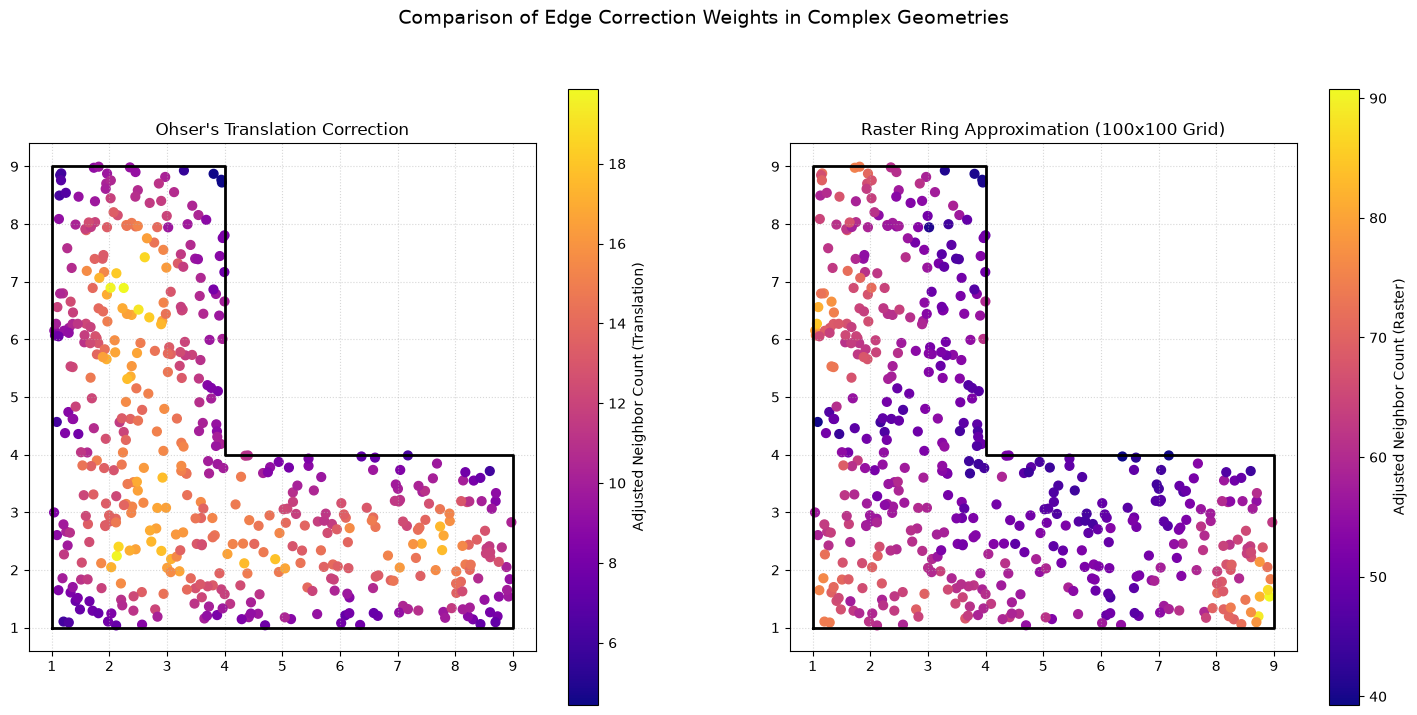

In [98]:
# %% [markdown]
# # Advanced Edge Corrections for Complex Boundaries: Translation & Raster Methods
# This notebook demonstrates how to implement Ohser's Translation Correction
# and a Discrete Pixel/Raster Approximation to resolve edge effects in complex polygons.

# %%
import numpy as np
import scipy.spatial as spatial
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point
from shapely.affinity import translate

# Set random seed for reproducibility
np.random.seed(42)

# %% [markdown]
# ## 1. Setup Complex Geometry and Point Pattern
# We initialize an irregular polygonal study zone and populate it with uniform points.

# %%
# Define vertices for an irregular L-shaped study window
boundary_vertices = [(1, 1), (1, 9), (4, 9), (4, 4), (9, 4), (9, 1)]
study_area = Polygon(boundary_vertices)
total_area = study_area.area

# Generate uniform points inside the polygon boundary
n_candidates = 800
bbox_x = np.random.uniform(1, 9, n_candidates)
bbox_y = np.random.uniform(1, 9, n_candidates)

points_inside = []
for x, y in zip(bbox_x, bbox_y):
    p = Point(x, y)
    if study_area.contains(p):
        points_inside.append([x, y])

coords = np.array(points_inside)
n_points = len(coords)
print(f"Analyzing {n_points} points inside an area of {total_area} units.")

# Define global evaluation radius
r_search = 1.2

# Build spatial index tree for neighbor identification
tree = spatial.KDTree(coords)

# %% [markdown]
# ## 2. Approach 1: Ohser's Translation Correction
# Instead of tracking circle arcs, we compute the intersecting overlap area between 
# the original study window ($W$) and a copy translated by the directional distance 
# vector separating each point pair.

# %%
# Find all pairs within the target radius
pairs = tree.query_pairs(r_search)

# Initialize array to store weights for each point (default weight = 1.0)
# We will scale up the weight value based on the translation overlap reduction
translation_weights = np.ones(n_points)

for i, j in pairs:
    coord_i = coords[i]
    coord_j = coords[j]
    
    # Calculate directional translation vector from i to j
    dx = coord_j[0] - coord_i[0]
    dy = coord_j[1] - coord_i[1]
    
    # Translate the entire polygon boundary geometry
    translated_study_area = translate(study_area, xoff=dx, yoff=dy)
    
    # Calculate the area of spatial intersection between original and shifted window
    overlap_area = study_area.intersection(translated_study_area).area
    
    if overlap_area > 0:
        # Ohser's weight formula: Total Area / Overlap Area
        pair_weight = total_area / overlap_area
        
        # Accumulate the inflated tracking count to both interacting points
        translation_weights[i] += (pair_weight - 1)
        translation_weights[j] += (pair_weight - 1)

print("Translation weights calculated via geometric polygon convolution shifts.")

# %% [markdown]
# ## 3. Approach 3: Discrete Raster / Pixel Approximation
# For highly complex shapes where polygon intersection math bogs down, we convert 
# the study area into a binary grid matrix. We approximate the circle's interior arc 
# by evaluating discrete points along a pixelated ring.

# %%
# Setup a high-resolution binary raster grid over our study area bounding box
grid_res = 100
x_grid = np.linspace(1, 9, grid_res)
y_grid = np.linspace(1, 9, grid_res)
X, Y = np.meshgrid(x_grid, y_grid)

# Create binary mask: 1 if inside polygon, 0 if outside
raster_mask = np.zeros_like(X, dtype=int)
for r in range(grid_res):
    for c in range(grid_res):
        if study_area.contains(Point(X[r, c], Y[r, c])):
            raster_mask[r, c] = 1

# Calculate pixel edge weights for every point
raster_weights = np.zeros(n_points)
n_angle_steps = 36  # Check every 10 degrees along the circle circumference

for i in range(n_points):
    center_x, center_y = coords[i]
    
    # Find all actual neighbors within radius to check
    neighbors = tree.query_ball_point(coords[i], r_search)
    neighbors.remove(i) # exclude self
    
    total_point_weight = 0
    for n_idx in neighbors:
        d_ij = np.linalg.norm(coords[i] - coords[n_idx])
        
        # Trace a discrete ring at distance d_ij to count inside vs outside pixels
        angles = np.linspace(0, 2 * np.pi, n_angle_steps, endpoint=False)
        test_x = center_x + d_ij * np.cos(angles)
        test_y = center_y + d_ij * np.sin(angles)
        
        # Map the continuous spatial coordinates back to closest matrix array indices
        col_indices = np.clip(((test_x - 1) / 8 * (grid_res - 1)).astype(int), 0, grid_res - 1)
        row_indices = np.clip(((test_y - 1) / 8 * (grid_res - 1)).astype(int), 0, grid_res - 1)
        
        # Count how many ring sample points land inside the valid raster mask
        samples_inside = np.sum(raster_mask[row_indices, col_indices])
        
        if samples_inside > 0:
            # Weight is the inverse of the proportion of the circle inside the boundary
            total_point_weight += (n_angle_steps / samples_inside)
            
    raster_weights[i] = total_point_weight

print("Pixel weights calculated using discrete angular raster queries.")

# %% [markdown]
# ## 4. Comparative Visualization
# We compare the weights generated by both methods side by side. Notice how both 
# techniques correctly isolate higher weights (warmer colors) on points close 
# to the peripheral edges and sharp corners.

# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
x_ext, y_ext = study_area.exterior.xy

# Plot 1: Translation Method
ax1.plot(x_ext, y_ext, color='black', linewidth=2)
sc1 = ax1.scatter(coords[:, 0], coords[:, 1], c=translation_weights, cmap='plasma', s=40)
fig.colorbar(sc1, ax=ax1, label='Adjusted Neighbor Count (Translation)')
ax1.set_title("Ohser's Translation Correction")
ax1.set_aspect('equal')
ax1.grid(True, linestyle=':', alpha=0.5)

# Plot 2: Raster/Pixel Approximation
ax2.plot(x_ext, y_ext, color='black', linewidth=2)
sc2 = ax2.scatter(coords[:, 0], coords[:, 1], c=raster_weights, cmap='plasma', s=40)
fig.colorbar(sc2, ax=ax2, label='Adjusted Neighbor Count (Raster)')
ax2.set_title(f'Raster Ring Approximation ({grid_res}x{grid_res} Grid)')
ax2.set_aspect('equal')
ax2.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Comparison of Edge Correction Weights in Complex Geometries', fontsize=14)
plt.show()

In [100]:
translation_weights[0:10]

array([10.00194322, 12.13052593, 12.08199136, 19.8701204 ,  9.26862735,
       13.24979981,  6.28717536, 15.57829574, 11.54066122, 14.38184676])

In [101]:
raster_weights[0:10]

array([59.76070611, 66.78565462, 46.02857143, 64.3012987 , 67.46762949,
       51.51176825, 71.92074592, 59.52265576, 52.86305592, 55.09451194])

Total Area of Study Window W = 16.0 square units

--- Step-by-Step Geometry for Point 0 -> Point 1 ---
Point 0 Coordinates: [2. 2.]
Point 1 Coordinates: [3.5 3.5]
Directional Vector (dx, dy): (1.50, 1.50)
Distance between points: 2.1213
Overlap Area (W ∩ W_x): 6.2500 square units
Ohser Edge-Correction Weight (w_ij): 2.5600
-> This pair counts as 2.5600 pairs instead of 1.0 to fix edge bias.

--- Processing All Valid Interactions Within Radius r = 2.5 ---
Point 0 connects to Point 1 | Distance: 2.12 | Weight: 2.5600
Point 0 connects to Point 2 | Distance: 2.12 | Weight: 2.5600
Point 1 connects to Point 0 | Distance: 2.12 | Weight: 2.5600
Point 2 connects to Point 0 | Distance: 2.12 | Weight: 2.5600


<>:123: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:128: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:123: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:128: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/35/j5f6qjb54wn_k9793l21kznw0000gn/T/ipykernel_19082/2996176628.py:123: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax.fill(o_x, o_y, color='purple', alpha=0.3, label=f'Overlap Area ($W \cap W_x$): {overlap_area:.2f}')
/var/folders/35/j5f6qjb54wn_k9793l21kznw0000

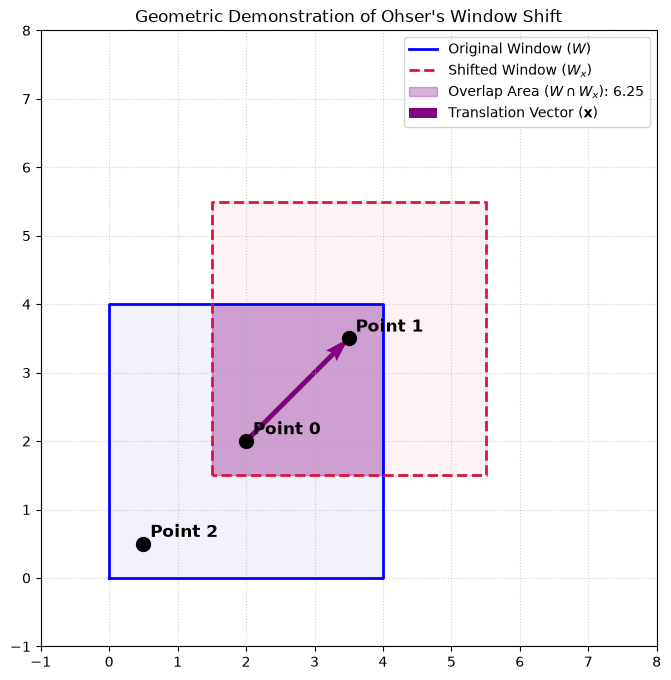

In [102]:
# %% [markdown]
# # Step-by-Step Breakdown of Ohser's Translation Correction
# This notebook demonstrates the exact geometric mechanics of Ohser's 
# translation correction using a minimal 3-point pattern inside a square window.

# %%
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely.affinity import translate

# %% [markdown]
# ## 1. Setup the Miniature Space
# We define a simple $4 \times 4$ square study window ($W$) and place 3 specific points:
# * Point 0: Right in the center (safe zone).
# * Point 1: Near the top-right corner.
# * Point 2: Near the bottom-left corner.

# %%
# Define a 4x4 square study window
study_window = Polygon([(0, 0), (0, 4), (4, 4), (4, 0)])
w_area = study_window.area
print(f"Total Area of Study Window W = {w_area} square units\n")

# Simple 3-point coordinate array
coords = np.array([
    [2.0, 2.0],  # Point 0 (Center)
    [3.5, 3.5],  # Point 1 (Top-Right Edge)
    [0.5, 0.5]   # Point 2 (Bottom-Left Edge)
])
n_points = len(coords)

# Set evaluation radius to bridge the points
r_search = 2.5

# %% [markdown]
# ## 2. Trace the Interaction and Apply Ohser's Translation Shifts
# We will iterate through a pair of interacting points to show how the directional
# translation vector shifts the window and computes the intersection area weight.

# %%
# We will explicitly analyze the interaction between Point 0 and Point 1
i = 0
j = 1

coord_i = coords[i]
coord_j = coords[j]

# Step A: Compute the directional translation vector (x) from i to j
dx = coord_j[0] - coord_i[0]
dy = coord_j[1] - coord_i[1]
translation_vector = np.array([dx, dy])

# Step B: Physically shift a copy of the entire study window by this vector
shifted_window = translate(study_window, xoff=dx, yoff=dy)

# Step C: Calculate the area of spatial intersection between original and shifted window
overlap_area = study_window.intersection(shifted_window).area

# Step D: Compute Ohser's Weight (Total Area / Overlap Area)
ohser_weight = w_area / overlap_area

print(f"--- Step-by-Step Geometry for Point {i} -> Point {j} ---")
print(f"Point {i} Coordinates: {coord_i}")
print(f"Point {j} Coordinates: {coord_j}")
print(f"Directional Vector (dx, dy): ({dx:.2f}, {dy:.2f})")
print(f"Distance between points: {np.linalg.norm(translation_vector):.4f}")
print(f"Overlap Area (W ∩ W_x): {overlap_area:.4f} square units")
print(f"Ohser Edge-Correction Weight (w_ij): {ohser_weight:.4f}")
print(f"-> This pair counts as {ohser_weight:.4f} pairs instead of 1.0 to fix edge bias.")

# %% [markdown]
# ## 3. Compute All-Pairs Correction Grid
# Let's run the calculation across all point permutations to build the full weight profile.

# %%
# Initialize tracking array for cumulative edge adjustments per point
final_adjusted_counts = np.zeros(n_points)

print("\n--- Processing All Valid Interactions Within Radius r = 2.5 ---")
for i in range(n_points):
    # Find all other points
    for j in range(n_points):
        if i == j:
            continue
            
        # Check if pair falls within our evaluation radius
        dist = np.linalg.norm(coords[i] - coords[j])
        if dist <= r_search:
            dx = coords[j][0] - coords[i][0]
            dy = coords[j][1] - coords[i][1]
            
            # Shift window and evaluate intersection
            W_shifted = translate(study_window, xoff=dx, yoff=dy)
            intersection_w = study_window.intersection(W_shifted).area
            weight = w_area / intersection_w
            
            # Accumulate weight
            final_adjusted_counts[i] += weight
            print(f"Point {i} connects to Point {j} | Distance: {dist:.2f} | Weight: {weight:.4f}")

# %% [markdown]
# ## 4. Visualize the Convoluted Window Overlap
# Let's visually check the window shift for our $0 \rightarrow 1$ pair to see the
# overlapping polygon area that derived our statistical correction weight.

# %%
fig, ax = plt.subplots(figsize=(8, 8))

# Plot Original Window W
w_x, w_y = study_window.exterior.xy
ax.plot(w_x, w_y, color='blue', linewidth=2, label='Original Window ($W$)')
ax.fill(w_x, w_y, color='blue', alpha=0.05)

# Plot Shifted Window W_x
s_x, s_y = shifted_window.exterior.xy
ax.plot(s_x, s_y, color='crimson', linestyle='--', linewidth=2, label='Shifted Window ($W_x$)')
ax.fill(s_x, s_y, color='crimson', alpha=0.05)

# Highlight Intersecting Overlap Area
overlap_poly = study_window.intersection(shifted_window)
o_x, o_y = overlap_poly.exterior.xy
ax.fill(o_x, o_y, color='purple', alpha=0.3, label=f'Overlap Area ($W \cap W_x$): {overlap_area:.2f}')

# Plot the points and the vector arrow connecting them
ax.scatter(coords[:, 0], coords[:, 1], color='black', s=100, zorder=5)
ax.quiver(coords[0, 0], coords[0, 1], dx, dy, angles='xy', scale_units='xy', scale=1, 
         color='purple', width=0.008, label='Translation Vector ($\mathbf{x}$)')

# Annotate points
for idx, pt in enumerate(coords):
    ax.text(pt[0] + 0.1, pt[1] + 0.1, f"Point {idx}", fontsize=12, fontweight='bold')

ax.set_xlim(-1, 8)
ax.set_ylim(-1, 8)
ax.set_aspect('equal')
ax.set_title("Geometric Demonstration of Ohser's Window Shift")
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')
plt.show()

Generated a 50x50 binary spatial matrix mask.

--- Step-by-Step Raster Correction Logs ---
Target Point Center: [2.5 3.2]
Total Ring Sample Points: 16
Points evaluated as INSIDE the boundary (1): 9
Points evaluated as OUTSIDE the boundary (0): 7
Calculated Isotropic Weight (w_ij): 1.7778
-> Every neighbor found on this ring will count as 1.7778 elements.


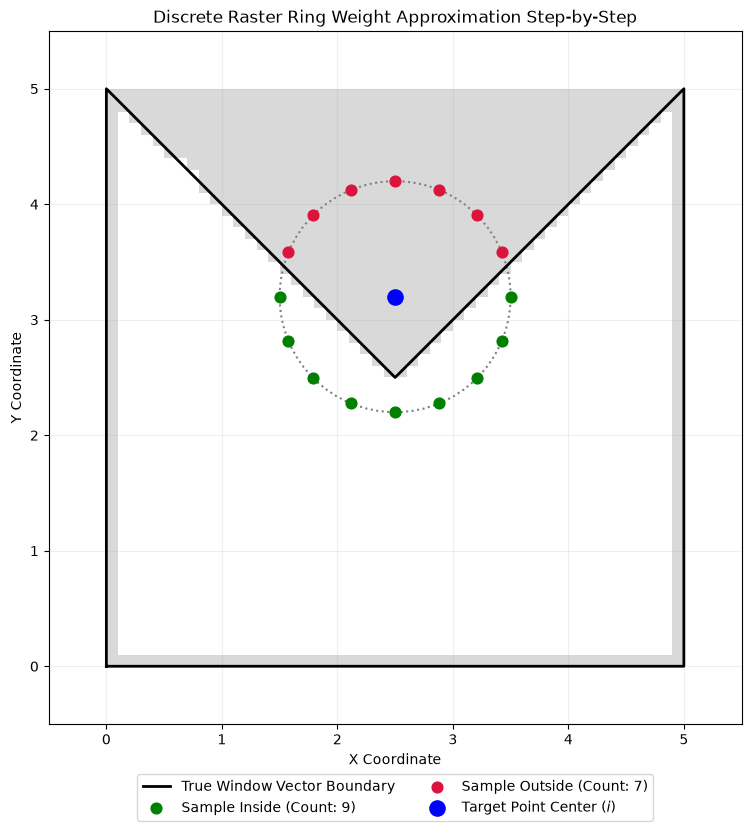

In [103]:
# %% [markdown]
# # Step-by-Step Breakdown of the Raster/Pixel Edge Approximation
# This notebook isolates the mathematical and indexing logic used to approximate 
# isotropic (circular) edge weights inside irregular geometries using a binary grid mask.

# %%
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point

# %% [markdown]
# ## 1. Define a Sharp, Jagged Edge Boundary
# We create an irregular wedge boundary to simulate a complex, non-rectangular window.
# We then place a single point near the corner edge to track its circle clipping.

# %%
# Define a complex polygon boundary (V-shaped indentation)
boundary_vertices = [(0, 0), (0, 5), (2.5, 2.5), (5, 5), (5, 0)]
study_window = Polygon(boundary_vertices)

# Position a single target point near the jagged inside edge
target_point = np.array([2.5, 3.2])
search_radius = 1.0

# %% [markdown]
# ## 2. Generate the Binary Raster Mask
# We discretize the continuous geometry into a $50 \times 50$ binary pixel matrix.
# 1 = Inside the polygon, 0 = Outside the polygon.

# %%
grid_res = 50
x_grid = np.linspace(0, 5, grid_res)
y_grid = np.linspace(0, 5, grid_res)
X, Y = np.meshgrid(x_grid, y_grid)

# Allocate and fill the binary grid mask
raster_mask = np.zeros_like(X, dtype=int)
for r in range(grid_res):
    for c in range(grid_res):
        if study_window.contains(Point(X[r, c], Y[r, c])):
            raster_mask[r, c] = 1

print(f"Generated a {grid_res}x{grid_res} binary spatial matrix mask.")

# %% [markdown]
# ## 3. Trace a Discrete Sample Ring around the Point
# Instead of doing analytical calculus, we generate 16 testing points 
# evenly spaced around a ring of radius $r=1.0$ centered at our point.

# %%
n_samples = 16
angles = np.linspace(0, 2 * np.pi, n_samples, endpoint=False)

# Compute continuous coordinates of the sample points on the ring
ring_x = target_point[0] + search_radius * np.cos(angles)
ring_y = target_point[1] + search_radius * np.sin(angles)

# Map continuous coordinates directly to the closest discrete matrix indices
# Using formula: index = ((coord - min) / span) * (res - 1)
col_indices = np.clip(((ring_x - 0) / 5.0 * (grid_res - 1)).astype(int), 0, grid_res - 1)
row_indices = np.clip(((ring_y - 0) / 5.0 * (grid_res - 1)).astype(int), 0, grid_res - 1)

# Look up values in our binary spatial matrix
pixel_values = raster_mask[row_indices, col_indices]
inside_count = np.sum(pixel_values)

# Calculate final edge-correction weight (Total samples / Samples inside)
isotropic_weight = n_samples / inside_count

print(f"\n--- Step-by-Step Raster Correction Logs ---")
print(f"Target Point Center: {target_point}")
print(f"Total Ring Sample Points: {n_samples}")
print(f"Points evaluated as INSIDE the boundary (1): {inside_count}")
print(f"Points evaluated as OUTSIDE the boundary (0): {n_samples - inside_count}")
print(f"Calculated Isotropic Weight (w_ij): {isotropic_weight:.4f}")
print(f"-> Every neighbor found on this ring will count as {isotropic_weight:.4f} elements.")

# %% [markdown]
# ## 4. Visualize the Raster Intersection
# Let's plot the matrix grid background, our target point, and the individual 
# ring sample points colored by whether they successfully landed inside or outside.

# %%
plt.figure(figsize=(9, 9))

# Plot the underlying binary raster grid background
plt.imshow(raster_mask, origin='lower', extent=[0, 5, 0, 5], cmap='bone', alpha=0.15)

# Plot True Continuous Polygon Boundary Lines
w_x, w_y = study_window.exterior.xy
plt.plot(w_x, w_y, color='black', linewidth=2, label='True Window Vector Boundary')

# Map and color-code the individual sampling pixels along the ring path
inside_mask = (pixel_values == 1)
outside_mask = (pixel_values == 0)

plt.scatter(ring_x[inside_mask], ring_y[inside_mask], color='green', s=60, 
            zorder=3, label=f'Sample Inside (Count: {inside_count})')
plt.scatter(ring_x[outside_mask], ring_y[outside_mask], color='crimson', s=60, 
            zorder=3, label=f'Sample Outside (Count: {n_samples - inside_count})')

# Plot search circle envelope trajectory
circle_patch = plt.Circle(target_point, search_radius, color='grey', fill=False, linestyle=':', linewidth=1.5)
plt.gca().add_patch(circle_patch)

# Plot the target origin center point
plt.scatter(target_point[0], target_point[1], color='blue', s=120, zorder=4, label='Target Point Center ($i$)')

plt.xlim(-0.5, 5.5)
plt.ylim(-0.5, 5.5)
plt.gca().set_aspect('equal')
plt.title('Discrete Raster Ring Weight Approximation Step-by-Step')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.grid(True, alpha=0.2)
plt.show()

In [105]:
16/9

1.7777777777777777


## Filtering

Find the minimum distance from each point to the window border

In [126]:
window =  [(1, 1), (1, 9), (4, 9), (4, 4), (9, 4), (9, 1)]
window = Polygon(window)

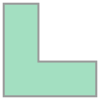

In [127]:
window

In [128]:
points = ppr.poisson(window, size=10, rng=rng)


In [129]:
points

array([[2.19201685, 3.39581842],
       [2.82833329, 7.25119476],
       [3.16820469, 7.94251967],
       [1.50698948, 4.11702724],
       [3.51799358, 5.78413246],
       [6.19152558, 3.6418593 ],
       [2.80216048, 2.56102872],
       [7.60629089, 3.99790575],
       [6.55486739, 2.70949121],
       [3.47919434, 7.11584511]])

In [130]:
window.area

39.0

In [131]:
max_radius = (window.area/2)**0.5

In [132]:
max_radius

4.415880433163924

In [133]:
min_distances = np.array([window.distance(Point(pt)) for pt in points])

In [134]:
min_distances

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

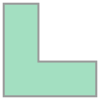

In [135]:
window

In [136]:
window.distance(Point(1.0, 10.))

1.0

In [137]:
window.distance?

Signature: window.distance(other)
Docstring: Unitless distance to other geometry (float).
File:      ~/projects/dev-pysal/pointpats/.pixi/envs/default/lib/python3.14/site-packages/shapely/geometry/base.py
Type:      method

In [139]:
import shapely
shapely_points = shapely.points(points[:, 0], points[:, 1])

# Compute the distances in a single vectorized C-call
min_distances_fast = shapely.distance(shapely_points, window.boundary)

In [140]:
min_distances_fast

array([1.19201685, 1.17166671, 0.83179531, 0.50698948, 0.48200642,
       0.3581407 , 1.56102872, 0.00209425, 1.29050879, 0.52080566])

In [141]:
import geopandas as gpd

In [143]:
W = gpd.GeoDataFrame(geometry=[window])

<Axes: >

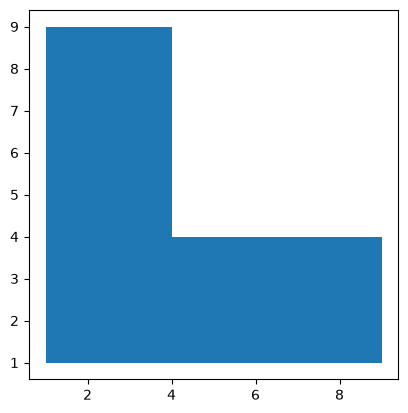

In [145]:
W.plot()

In [150]:
pnt_df = gpd.GeoDataFrame(geometry=shapely_points,
                         data=min_distances_fast,
                         columns=['d2w'])

<Axes: >

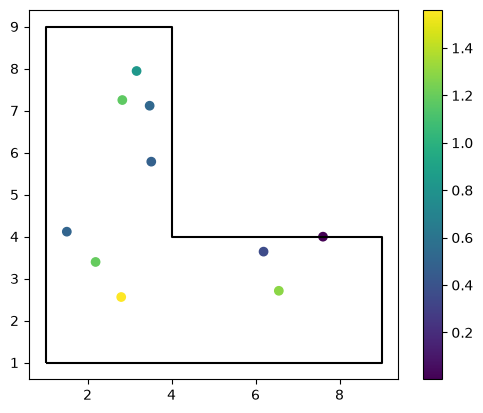

In [155]:
base = W.boundary.plot(color='k')
pnt_df.plot(column='d2w', legend=True, ax=base)

In [156]:
def max_radius(area):
    return (area/2)**0.5

In [157]:
max_radius(1)

0.7071067811865476

In [158]:
4**0.5

2.0

In [159]:
0.5**0.5

0.7071067811865476

In [169]:
def max_radius(study_window):
    """
    Calculates the maximum safe search radius for Ripley's K-function.
    Caps the radius at half the length of the shortest side of the bounding box.
    
    Parameters:
    -----------
    study_window : shapely.geometry.Polygon
        The spatial geometry representing the study area.
        
    Returns:
    --------
    float
        The maximum recommended search radius.
    """
    # Get the bounding box coordinates: (minx, miny, maxx, maxy)
    minx, miny, maxx, maxy = study_window.total_bounds
    
    # Calculate the width and height of the study area
    width = maxx - minx
    height = maxy - miny
    
    # Target half of the shortest dimension
    return min(width, height) / 2.0

In [170]:
max_radius(W)

np.float64(4.0)

In [171]:
import numpy as np
import shapely
from shapely.geometry import Polygon
import geopandas as gpd

def max_radius(study_window):
    """
    Calculates the maximum safe search radius for Ripley's K-function.
    Caps the radius at half the length of the shortest side of the bounding box.
    
    Parameters:
    -----------
    study_window : geopandas.GeoDataFrame, shapely.geometry.Polygon, or numpy.ndarray
        The spatial geometry representing the study area. If a numpy array, 
        it should have a shape of (N, 2) representing the polygon coordinates.
        
    Returns:
    --------
    float
        The maximum recommended search radius.
    """
    # 1. Handle GeoDataFrame
    if isinstance(study_window, gpd.GeoDataFrame):
        minx, miny, maxx, maxy = study_window.total_bounds
        
    # 2. Handle Shapely Geometry (Polygon, MultiPolygon, etc.)
    elif isinstance(study_window, shapely.geometry.base.BaseGeometry):
        minx, miny, maxx, maxy = study_window.bounds
        
    # 3. Handle NumPy array of coordinates
    elif isinstance(study_window, np.ndarray):
        # Ensure it's a 2D array of coordinates
        if study_window.ndim != 2 or study_window.shape[1] != 2:
            raise ValueError("NumPy array must have a shape of (N, 2) representing polygon coordinates.")
        
        # Create a temporary Shapely polygon to extract bounds safely
        poly = Polygon(study_window)
        minx, miny, maxx, maxy = poly.bounds
        
    else:
        raise TypeError("study_window must be a GeoDataFrame, Shapely geometry, or an (N,2) NumPy array.")
    
    # Calculate the width and height of the bounding box
    width = maxx - minx
    height = maxy - miny
    
    # Return half of the shortest dimension
    return min(width, height) / 2.0

In [172]:
max_radius(W)

np.float64(4.0)

In [173]:
erroded_area = W.buffer(-4.0)

In [174]:
erroded_area.area

0    0.0
dtype: float64

In [175]:
tree = KDTree(points)

In [177]:
import scipy.spatial.distance as distance

In [178]:
dists = distance.pdist(points)

In [179]:
np.max(dists)

np.float64(6.233303388312588)

In [180]:
import numpy as np
import shapely
from shapely.geometry import Polygon
import geopandas as gpd
import scipy.spatial.distance as distance
from scipy.spatial import ConvexHull

def max_radius(study_window, points=None, method='bbox', pct=0.25):
    """
    Calculates the maximum search radius for Ripley's K-function, 
    with specialized handling for highly concave polygons.
    
    Parameters:
    -----------
    study_window : geopandas.GeoDataFrame, shapely.geometry.Polygon, or numpy.ndarray
        The spatial geometry representing the study area.
    points : numpy.ndarray, optional
        An (N, 2) array of point coordinates. Required if method='distance_pct'.
    method : str, default 'bbox'
        Options:
          'bbox'         : Half the length of the shortest side of the bounding box.
          'distance_pct' : A specified percentile of the pairwise distance distribution.
    pct : float, default 0.25
        The percentile (expressed as a fraction between 0 and 1) of the pairwise 
        distances to use when method='distance_pct'. Default is the 25th percentile (Q1).
        
    Returns:
    --------
    float
        The calculated maximum search radius.
    """
    
    if method == 'bbox':
        # --- Existing Bounding Box Logic ---
        if isinstance(study_window, gpd.GeoDataFrame):
            minx, miny, maxx, maxy = study_window.total_bounds
        elif isinstance(study_window, shapely.geometry.base.BaseGeometry):
            minx, miny, maxx, maxy = study_window.bounds
        elif isinstance(study_window, np.ndarray):
            if study_window.ndim != 2 or study_window.shape[1] != 2:
                raise ValueError("NumPy array must be shape (N, 2) for polygon coordinates.")
            minx, miny, maxx, maxy = Polygon(study_window).bounds
        else:
            raise TypeError("Invalid study_window type for bounding box calculation.")
            
        return min(maxx - minx, maxy - miny) / 2.0

    elif method == 'distance_pct':
        if points is None:
            raise ValueError("The 'points' array must be provided to use the 'distance_pct' method.")
        if not (0.0 < pct <= 1.0):
            raise ValueError("The 'pct' parameter must be a float between 0.0 and 1.0.")
            
        n_points = len(points)
        
        # Optimization: If N is huge, use the Convex Hull vertices to estimate distances 
        # or sample a subset of points to avoid memory allocation overflow.
        if n_points > 10000:
            # Option A: Subsample 5,000 points randomly for an ultra-fast approximation
            idx = np.random.choice(n_points, size=5000, replace=False)
            sample_points = points[idx]
            pairwise_dists = distance.pdist(sample_points)
        else:
            # Option B: Direct calculation for smaller arrays
            pairwise_dists = distance.pdist(points)
            
        # Return the requested percentile (e.g., 0.25 for the first quartile)
        return float(np.percentile(pairwise_dists, pct * 100))
        
    else:
        raise ValueError("Method must be either 'bbox' or 'distance_pct'.")

In [181]:
max_radius(W)

np.float64(4.0)

In [183]:
max_radius(W, points)

np.float64(4.0)

In [184]:
max_radius(W, points, method='distance_pct')

2.1865469645527256

In [186]:
erroded_area = W.buffer(-(max_radius(W, points, method='distance_pct')))
erroded_area.area

0    0.0
dtype: float64

In [191]:
import numpy as np
import shapely
from shapely.geometry import Polygon
import geopandas as gpd
import scipy.spatial.distance as distance

def max_radius(study_window, points=None, method='bbox', pct=0.25, min_core_nodes=0.5):
    """
    Calculates the maximum search radius for Ripley's K-function, with specialized
    handling for concave windows, point distance distributions, or border erosion constraints.
    
    Parameters:
    -----------
    study_window : geopandas.GeoDataFrame, shapely.geometry.Polygon, or numpy.ndarray
        The spatial geometry representing the study area.
    points : numpy.ndarray, optional
        An (N, 2) array of point coordinates. Required for 'distance_pct' and 'erosion_threshold'.
    method : str, default 'bbox'
        Options:
          'bbox'              : Half the length of the shortest side of the bounding box.
          'distance_pct'      : A specified percentile of the pairwise distance distribution.
          'erosion_threshold' : Max radius that guarantees a minimum number of core points.
    pct : float, default 0.25
        The percentile (0.0 to 1.0) used when method='distance_pct'.
    min_core_nodes : int or float, default 0.5
        Used when method='erosion_threshold'. If a float between 0.0 and 1.0, it is treated 
        as a percentage of the total points. If an integer > 1, it is the absolute minimum 
        number of target core points required.
        
    Returns:
    --------
    float
        The calculated maximum search radius.
    """
    # --- 1. Standardize the Window Geometry to a Shapely Base Geometry ---
    if isinstance(study_window, gpd.GeoDataFrame):
        polygon_geometry = study_window.union_all()
        minx, miny, maxx, maxy = study_window.total_bounds
    elif isinstance(study_window, shapely.geometry.base.BaseGeometry):
        polygon_geometry = study_window
        minx, miny, maxx, maxy = study_window.bounds
    elif isinstance(study_window, np.ndarray):
        if study_window.ndim != 2 or study_window.shape[1] != 2:
            raise ValueError("NumPy array must be shape (N, 2) for polygon coordinates.")
        polygon_geometry = Polygon(study_window)
        minx, miny, maxx, maxy = polygon_geometry.bounds
    else:
        raise TypeError("Invalid study_window type.")

    # --- 2. Method Branches ---
    if method == 'bbox':
        return min(maxx - minx, maxy - miny) / 2.0

    elif method == 'distance_pct':
        if points is None:
            raise ValueError("The 'points' array is required for 'distance_pct'.")
        if len(points) > 10000:
            idx = np.random.choice(len(points), size=5000, replace=False)
            pairwise_dists = distance.pdist(points[idx])
        else:
            pairwise_dists = distance.pdist(points)
        return float(np.percentile(pairwise_dists, pct * 100))

    elif method == 'erosion_threshold':
        if points is None:
            raise ValueError("The 'points' array is required for 'erosion_threshold'.")
        
        n_points = len(points)
        
        # Normalize the threshold to an absolute count of points
        if isinstance(min_core_nodes, float) and 0.0 < min_core_nodes <= 1.0:
            target_count = int(np.ceil(min_core_nodes * n_points))
        elif isinstance(min_core_nodes, (int, np.integer)) and min_core_nodes > 1:
            target_count = min_core_nodes
        else:
            raise ValueError("min_core_nodes must be a percentage (float 0-1) or an absolute count (int > 1).")
            
        if target_count > n_points:
            raise ValueError("Requested minimum core nodes exceeds the total number of points.")

        # Vectorized optimization: Compute the shortest distance from EVERY point to the border
        shapely_points = shapely.points(points[:, 0], points[:, 1])
        distances_to_border = shapely.distance(shapely_points, polygon_geometry.boundary)
        
        # Sort the distances in descending order
        # The largest distances represent points deepest inside the core
        sorted_distances = np.sort(distances_to_border)[::-1]
        
        # To keep exactly 'target_count' points in the core, the maximum allowable 
        # erosion buffer radius is the distance value at that specific rank index.
        max_r_allowed = sorted_distances[target_count - 1]
        
        return float(max_r_allowed)
        
    else:
        raise ValueError("Invalid method specified.")

In [192]:
max_radius(W, points, method='distance_pct')

2.1865469645527256

In [193]:
max_radius(W, points, method='erosion_threshold')

0.8317953078796494

In [ ]:
max_radius(W, points, method='erosion_threshold')

In [194]:
erroded_area = W.buffer(-(max_radius(W, points, method='distance_pct')))
erroded_area.area

0    0.0
dtype: float64

In [195]:
erroded_area = W.buffer(-(max_radius(W, points, method='erosion_threshold')))
erroded_area.area

0    15.299436
dtype: float64

<Axes: >

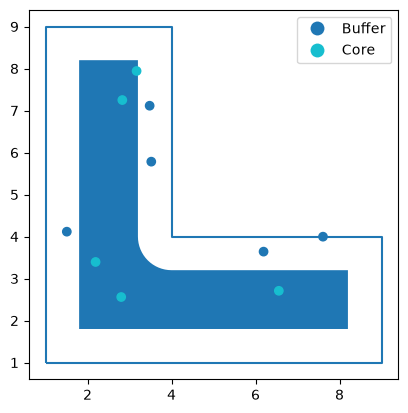

In [210]:
base = W.boundary.plot()
gpd.GeoSeries([eroded_area]).plot(ax=base)
core = [eroded_area.contains(Point(pnt)) for pnt in points]
pnt_df['core'] = np.where(core, "Core", "Buffer")
pnt_df.plot(column='core', legend=True, categorical=True,ax=base)


In [206]:
core = [eroded_area.contains(Point(pnt)) for pnt in points]

In [207]:
core

[True, True, True, False, False, False, True, False, True, False]

In [200]:
W.area

0    39.0
dtype: float64

AttributeError: 'Polygon' object has no attribute 'plot'

In [211]:
from pointpats.geometry import max_radius

ImportError: cannot import name 'max_radius' from 'pointpats.geometry' (/Users/serge/projects/dev-pysal/pointpats/pointpats/geometry.py)

## `localK` and `localL`

`pointpats` provides per-point versions of Ripley's K and L functions, following
the `localK` / `localKengine` logic in the R package *spatstat* (Baddeley & Turner 2005).

For each point $i$, $K_i(r)$ counts the expected number of additional points within
distance $r$, normalised by $\lambda_1 = (n-1)/|W|$.  For a CSR pattern,
$E[K_i(r)] = \pi r^2$.  The local L is simply $L_i(r) = \sqrt{K_i(r)/\pi}$.

Three edge corrections are supported: `None` (uncorrected), `'isotropic'` (Ripley,
the default, matching spatstat's `correction="Ripley"`), and `'translate'` (Ohser & Stoyan).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely
from pointpats import localK, localL
from pointpats import random as ppr

rng = np.random.default_rng(42)
window = shapely.box(0, 0, 10, 10)
points = ppr.poisson(window, size=80, rng=rng)
print(f"{len(points)} points in a 10×10 window")

In [ ]:
# Local K with isotropic edge correction (spatstat default)
support, lk = localK(points, hull=window, support=20)

fig, ax = plt.subplots(figsize=(8, 4))
for i in range(len(points)):
    ax.plot(support, lk[:, i], color="gray", alpha=0.25, lw=0.7)
ax.plot(support, lk.mean(axis=1), color="red", lw=2, label=r"mean $K_i(r)$")
ax.plot(support, np.pi * support**2, "k--", lw=1.5, label=r"CSR: $\pi r^2$")
ax.set_xlabel("r")
ax.set_ylabel(r"$K_i(r)$")
ax.set_title("Local K function (isotropic edge correction)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Linearised local L: L_i(r) - r, centred on 0 for CSR
support, ll_lin = localL(points, hull=window, support=20, linearized=True)

fig, ax = plt.subplots(figsize=(8, 4))
for i in range(len(points)):
    ax.plot(support, ll_lin[:, i], color="steelblue", alpha=0.2, lw=0.7)
ax.plot(support, ll_lin.mean(axis=1), color="navy", lw=2, label=r"mean $L_i(r) - r$")
ax.axhline(0, color="k", lw=1.5, ls="--", label="CSR = 0")
ax.set_xlabel("r")
ax.set_ylabel(r"$L_i(r) - r$")
ax.set_title("Local L function, linearised (isotropic edge correction)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Map: colour each point by its local K value at a chosen radius
r_target = 2.0
r_idx = np.argmin(np.abs(support - r_target))
ki_at_r = lk[r_idx]   # K_i(r_target) for every point

shapely_pts = shapely.points(points[:, 0], points[:, 1])
pnt_gdf = gpd.GeoDataFrame({"K_local": ki_at_r}, geometry=shapely_pts)
win_gdf = gpd.GeoDataFrame(geometry=[window])

fig, ax = plt.subplots(figsize=(6, 6))
win_gdf.boundary.plot(ax=ax, color="k")
pnt_gdf.plot(
    column="K_local", legend=True, ax=ax,
    markersize=50, cmap="RdYlGn",
    legend_kwds={"label": f"$K_i$(r={r_target})"},
)
ax.set_title(f"Local K at r = {r_target}: high = clustered, low = isolated")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [ ]:
# Compare edge corrections for a single point
support, lk_none = localK(points, hull=window, support=20, edge_correction=None)
support, lk_iso  = localK(points, hull=window, support=20, edge_correction="isotropic")
support, lk_tra  = localK(points, hull=window, support=20, edge_correction="translate")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(support, lk_none[:, 0], label="uncorrected", ls=":")
ax.plot(support, lk_iso[:, 0],  label="isotropic",   ls="-")
ax.plot(support, lk_tra[:, 0],  label="translate",   ls="--")
ax.plot(support, np.pi * support**2, "k-.", lw=1, label=r"CSR: $\pi r^2$")
ax.set_xlabel("r")
ax.set_ylabel(r"$K_i(r)$  [point 0]")
ax.set_title("Edge correction comparison for a single point")
ax.legend()
plt.tight_layout()
plt.show()